# E5 — Accelerator: CPU vs Hailo-10H

## Research question

**RQ5.** What performance and energy gains does the Hailo-10H accelerator
provide with respect to CPU execution?

## Prior hypothesis

Hailo-10H should provide a significant throughput speedup.

## Experiment configuration

| Parameter | Values |
|-----------|---------|
| Accelerator | CPU (False) vs Hailo-10H (True) |
| Models | Model optimized for Hailo |
| Total | CPU/Hailo pairs |


In [ ]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Data loading (E5) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "TFG-DATA" / "E5"

_EMPTY_COLS = ["run_id", "model_label", "engine", "test_type", "batch_size",
               "context_size", "fan", "accelerator", "tokens_per_s_mean",
               "words_per_s_mean", "latency_ms_mean", "ttft_ms_mean",
               "perplexity_geomean", "temp_max_c", "temp_mean_c",
               "power_max_w", "watt_min_w", "watt_max_w",
               "throttled_ratio", "energy_per_token_j",
               "cpu_work_core_s", "cpu_efficiency",
               "n_empty_generations", "mbu_pct", "model_size_gb"]

# Pre-declaration for the IDE: values assigned in the following if/else
hw_full: pd.DataFrame = pd.DataFrame()
pm_full: pd.DataFrame = pd.DataFrame()
coll: RunCollection
summary: pd.DataFrame
ex: pd.DataFrame
fom_red_df: pd.DataFrame

if not DATA_ROOT.is_dir():
    print(f"WARNING: E5 directory not found: {DATA_ROOT.resolve()}")
    coll = RunCollection(runs=[])
    summary = pd.DataFrame(columns=_EMPTY_COLS)
    hw_full = pd.DataFrame()
    pm_full = pd.DataFrame()
    ex = pd.DataFrame(columns=_EMPTY_COLS)
    fom_red_df = pd.DataFrame()
else:
    coll = load_collection(DATA_ROOT)
    print(f"Runs loaded E5: {len(coll)}")

    summary = coll.summary_df()
    hw_full  = coll.hw_metrics_df()
    pm_full  = coll.prompt_metrics_df()

    ex = summary[summary["test_type"] == "TYPE_1"].copy()
    # model_base: strip engine suffix (L)/(O)/(H) to pair CPU↔Hailo
    ex["model_base"] = (
        ex["model_label"]
        .str.replace(r'\s*\([LOH]\)\s*', '', regex=True)
        .str.strip()
    )

    _accels = sorted(bool(a) for a in ex["accelerator"].unique())
    print(f"Runs in E5: {ex.shape[0]}  |  Accelerators: {_accels}")

    # --- FoM_red = sqrt(T_norm · ε_norm), CPU anchor for the same model ---
    _cpu_ex   = ex[~ex["accelerator"]].set_index("model_base")
    _hailo_ex = ex[ex["accelerator"]].set_index("model_base")
    _models_paired = sorted(set(_cpu_ex.index) & set(_hailo_ex.index))

    _rows = []
    for _m in _models_paired:
        _c = _cpu_ex.loc[_m]
        _h = _hailo_ex.loc[_m]
        T_cpu    = float(_c["tokens_per_s_mean"])
        T_h      = float(_h["tokens_per_s_mean"])
        J_cpu    = float(_c["energy_per_token_j"])
        J_h      = float(_h["energy_per_token_j"])
        T_norm   = T_h / T_cpu
        eps_norm = J_cpu / J_h
        fom_red  = float(np.sqrt(T_norm * eps_norm))
        _rows.append({
            "model_base": _m,
            "tok/s CPU": T_cpu, "tok/s Hailo": T_h,    "T_norm": T_norm,
            "J/tok CPU": J_cpu, "J/tok Hailo": J_h,    "ε_norm": eps_norm,
            "FoM_red": fom_red,
        })
    fom_red_df = pd.DataFrame(_rows)

    # Usability: T_hum from minimum reading speed (3 words/s)
    if not pm_full.empty:
        from monitorviz.transforms.fom import compute_usability
        ex, _ = compute_usability(ex, pm_full)
    else:
        ex["T_hum"] = np.nan
        ex["usable"] = False

    if fom_red_df.empty:
        print("WARNING: no CPU↔Hailo pairs — add the Hailo runs to the data submodule")
    else:
        print(fom_red_df.round(3))


# 📊 Figures and tables for the thesis


In [ ]:
# E5 master table — CPU vs Hailo by model (context: 2048 tokens)
# T_norm = tok/s_Hailo / tok/s_CPU  |  ε_norm = J/tok_CPU / J/tok_Hailo
# FoM_red = sqrt(T_norm · ε_norm)   [N cancels out since it's the same model]
if not fom_red_df.empty:
    _disp = fom_red_df.copy()
    _disp.columns = [
        "Model", "tok/s CPU", "tok/s Hailo", "T_norm",
        "J/tok CPU", "J/tok Hailo", "ε_norm", "FoM_red",
    ]

    # σ tok/s by model from pm_full (intra-run variability)
    if not pm_full.empty and "run_id" in pm_full.columns and "accelerator" in ex.columns:
        _pm_tmp = pm_full.drop(columns=["accelerator"], errors="ignore")
        _pm_e5 = _pm_tmp.merge(ex[["run_id", "model_base", "accelerator"]], on="run_id", how="left")
        _valid5 = (_pm_e5[~_pm_e5["is_empty_generation"]]
                   if "is_empty_generation" in _pm_e5.columns else _pm_e5)
        if "tokens_per_second" in _valid5.columns and "model_base" in _valid5.columns:
            _std_cpu5   = _valid5[~_valid5["accelerator"]].groupby("model_base")["tokens_per_second"].std()
            _std_hailo5 = _valid5[ _valid5["accelerator"]].groupby("model_base")["tokens_per_second"].std()
            _disp["σ tok/s CPU"]   = fom_red_df["model_base"].map(_std_cpu5).round(2).values
            _disp["σ tok/s Hailo"] = fom_red_df["model_base"].map(_std_hailo5).round(2).values
            # Reorder: σ next to its mean
            _col_order = ["Model", "tok/s CPU", "σ tok/s CPU",
                          "tok/s Hailo", "σ tok/s Hailo",
                          "T_norm", "J/tok CPU", "J/tok Hailo", "ε_norm", "FoM_red"]
            _col_order = [c for c in _col_order if c in _disp.columns]
            _disp = _disp[_col_order]

    # Usable: does Hailo exceed T_hum?
    _t_hum_map = (
        ex[~ex["accelerator"] & ex["T_hum"].notna()]
        .set_index("model_base")["T_hum"]
        if "T_hum" in ex.columns else pd.Series(dtype=float)
    )
    _usable_hailo = []
    for _, row in fom_red_df.iterrows():
        _t_hum_ref = _t_hum_map.get(row["model_base"], np.nan)
        _usable_hailo.append(
            "✓" if (not np.isnan(_t_hum_ref) and row["tok/s Hailo"] >= _t_hum_ref) else "✗"
        )
    _disp["Usable (H)"] = _usable_hailo
    _disp["Usable (C)"] = [
        "✓" if (not np.isnan(_t_hum_map.get(r["model_base"], np.nan))
                and r["tok/s CPU"] >= _t_hum_map.get(r["model_base"], np.nan))
        else "✗"
        for _, r in fom_red_df.iterrows()
    ]

    display(_disp.round(3))
    print("\nNote: context used = 2048 tokens in both configurations (CPU and Hailo).")
    print("Note: FoM_red > 1 → Hailo has a better performance/energy balance than CPU")
    print("⁽¹⁾ J/tok (both configurations) computed from external power meter (total_kwh).")
    print("    The measurement includes system power-on and ~5 min of idle outside the")
    print("    inference window; values are upper bounds, comparable to each other.")
else:
    print("No data for comparison table")



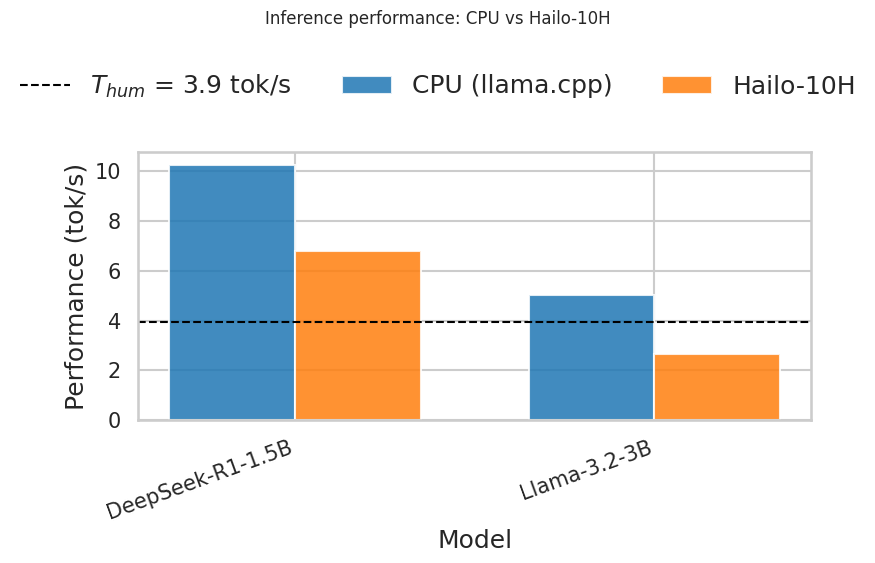

In [3]:
# Fig 1 — Performance: tok/s CPU vs Hailo with T_hum usability threshold
if not fom_red_df.empty:
    _models1 = fom_red_df["model_base"].tolist()
    _x1 = np.arange(len(_models1))
    _w1 = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(_x1 - _w1/2, fom_red_df["tok/s CPU"],   _w1,
           label="CPU (llama.cpp)", color="tab:blue",   alpha=0.85)
    ax.bar(_x1 + _w1/2, fom_red_df["tok/s Hailo"], _w1,
           label="Hailo-10H",       color="tab:orange", alpha=0.85)

    # T_hum line — mean of CPU runs with T_hum available
    _t_hum_vals1 = ex[~ex["accelerator"] & ex["T_hum"].notna()]["T_hum"]
    if not _t_hum_vals1.empty:
        _t_hum1 = float(_t_hum_vals1.mean())
        ax.axhline(_t_hum1, ls="--", color="black", lw=1.5,
                   label=f"$T_{{hum}}$ = {_t_hum1:.1f} tok/s")

    ax.set_xticks(_x1)
    ax.set_xticklabels(_models1, rotation=20, ha='right')
    ax.set_ylabel("Performance (tok/s)")
    ax.set_xlabel("Model")
    fig.suptitle("Inference performance: CPU vs Hailo-10H", y=1.14, fontsize=12)
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("No data")


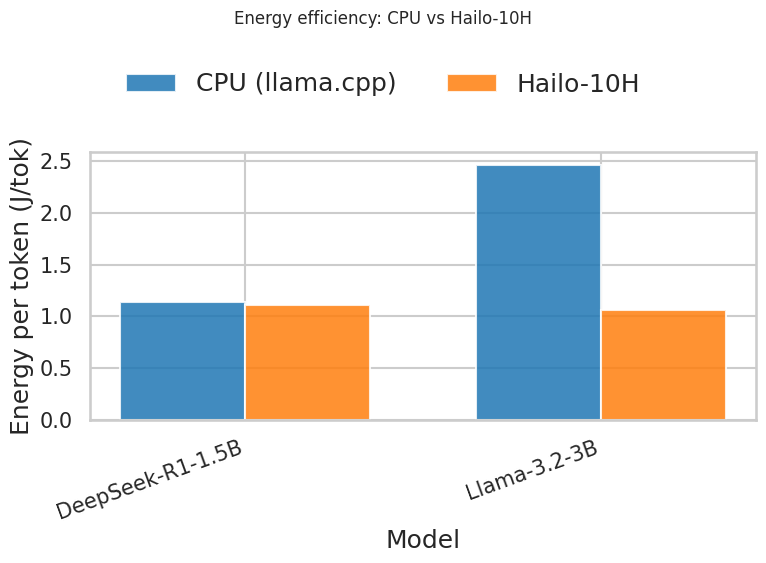

⁽¹⁾ J/tok computed from external power meter (total_kwh) in both configurations.
    The measurement includes system power-on and ~5 min of idle outside the
    inference window; values are upper bounds, comparable to each other.


In [4]:
# Fig 2 — Energy efficiency: J/tok CPU vs Hailo
if not fom_red_df.empty:
    _models2 = fom_red_df["model_base"].tolist()
    _x2 = np.arange(len(_models2))
    _w2 = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(_x2 - _w2/2, fom_red_df["J/tok CPU"],   _w2,
           label="CPU (llama.cpp)", color="tab:blue",   alpha=0.85)
    ax.bar(_x2 + _w2/2, fom_red_df["J/tok Hailo"], _w2,
           label="Hailo-10H",       color="tab:orange", alpha=0.85)
    ax.set_xticks(_x2)
    ax.set_xticklabels(_models2, rotation=20, ha='right')
    ax.set_ylabel("Energy per token (J/tok)")
    ax.set_xlabel("Model")
    fig.suptitle("Energy efficiency: CPU vs Hailo-10H", y=1.14, fontsize=12)
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()
    print("⁽¹⁾ J/tok computed from external power meter (total_kwh) in both configurations.")
    print("    The measurement includes system power-on and ~5 min of idle outside the")
    print("    inference window; values are upper bounds, comparable to each other.")
else:
    print("No data")


<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_254090/2704523155.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.axhline(1.0, ls="--", color="black", lw=1.5, label="Baseline CPU (FoM$_\mathrm{red}$ = 1)")


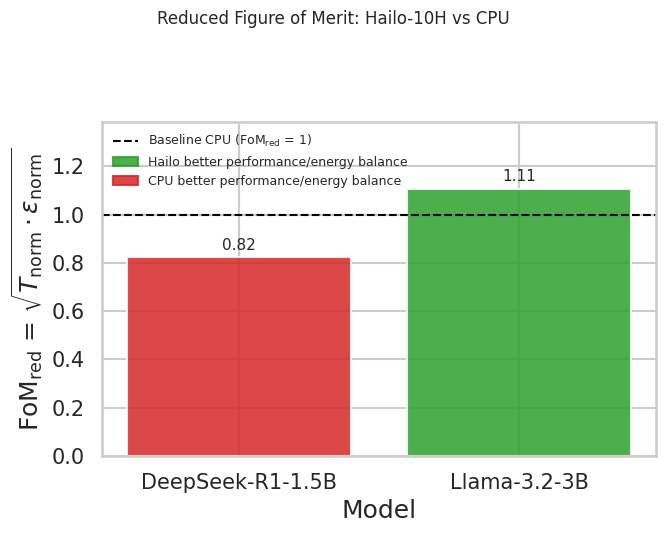

In [5]:
# Fig 3 — FoM_red by model (green > 1 = Hailo better balance, red < 1 = CPU better)
if not fom_red_df.empty:
    from matplotlib.patches import Patch

    _models3  = fom_red_df["model_base"].tolist()
    _fom_vals = fom_red_df["FoM_red"].tolist()
    _colors3  = ["tab:green" if v >= 1.0 else "tab:red" for v in _fom_vals]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(_models3, _fom_vals, color=_colors3, alpha=0.85)
    ax.axhline(1.0, ls="--", color="black", lw=1.5, label="Baseline CPU (FoM$_\mathrm{red}$ = 1)")
    for bar, v in zip(bars, _fom_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=11)
    ax.set_ylabel(r"FoM$_\mathrm{red}$ = $\sqrt{T_\mathrm{norm}\cdot\varepsilon_\mathrm{norm}}$")
    ax.set_xlabel("Model")
    fig.suptitle("Reduced Figure of Merit: Hailo-10H vs CPU", y=1.08, fontsize=12)
    ax.set_ylim(0, max(_fom_vals) * 1.25)
    _handles = [
        ax.get_legend_handles_labels()[0][0],
        Patch(color="tab:green", alpha=0.85, label="Hailo better performance/energy balance"),
        Patch(color="tab:red",   alpha=0.85, label="CPU better performance/energy balance"),
    ]
    ax.legend(handles=_handles, frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print("No data")


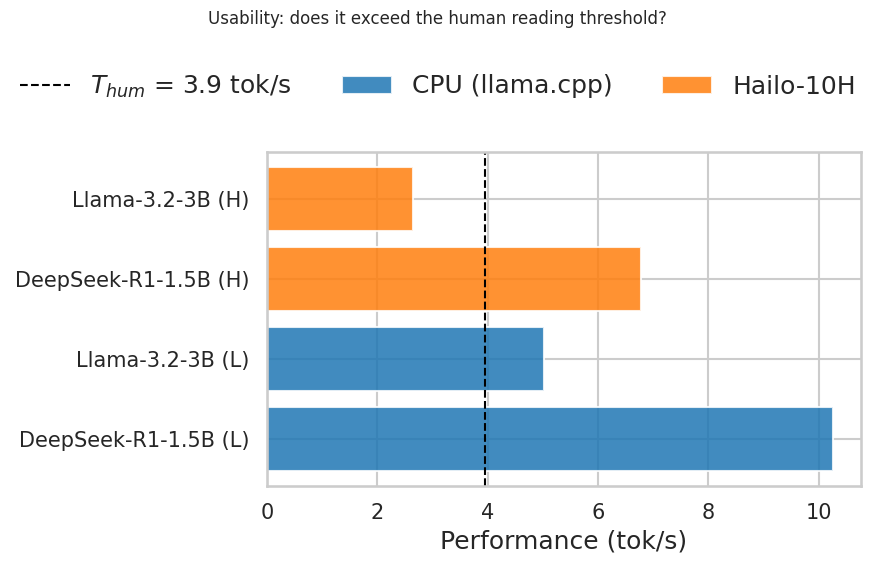

In [6]:
# Fig 4 — Usability: tok/s CPU vs Hailo with T_hum threshold
if not ex.empty:
    _cpu_ex4   = ex[~ex["accelerator"]].copy()
    _hailo_ex4 = ex[ex["accelerator"]].copy()

    # Sort by tok/s CPU descending
    _order4 = (
        _cpu_ex4.sort_values("tokens_per_s_mean", ascending=False)["model_label"].tolist()
        + _hailo_ex4.sort_values("tokens_per_s_mean", ascending=False)["model_label"].tolist()
    )
    _all4 = pd.concat([_cpu_ex4, _hailo_ex4])

    _palette4 = {False: "tab:blue", True: "tab:orange"}
    _labels4  = {False: "CPU (llama.cpp)", True: "Hailo-10H"}

    fig, ax = plt.subplots(figsize=(9, 5))
    for _acc, _grp in _all4.groupby("accelerator"):
        ax.barh(
            _grp["model_label"],
            _grp["tokens_per_s_mean"],
            color=_palette4[_acc], alpha=0.85, label=_labels4[_acc],
        )

    # T_hum threshold
    _t_hum_vals4 = ex[~ex["accelerator"] & ex["T_hum"].notna()]["T_hum"]
    if not _t_hum_vals4.empty:
        _t_hum4 = float(_t_hum_vals4.mean())
        ax.axvline(_t_hum4, ls="--", color="black", lw=1.5,
                   label=f"$T_{{hum}}$ = {_t_hum4:.1f} tok/s")

    ax.set_xlabel("Performance (tok/s)")
    fig.suptitle("Usability: does it exceed the human reading threshold?", y=1.14, fontsize=12)
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("No data")


# 📎 APPENDIX


In [7]:
# ── Appendix: E5 comparison tables (inference + hardware with σ) ──────────────
if not ex.empty:
    _df_ann5 = ex.copy()

    # σ inference from pm_full per prompt
    if not pm_full.empty and "run_id" in pm_full.columns and "run_id" in _df_ann5.columns:
        _valid5 = (pm_full[~pm_full["is_empty_generation"]]
                   if "is_empty_generation" in pm_full.columns else pm_full)
        _si5 = [c for c in ["tokens_per_second","time_to_first_token_ms","perplexity"]
                if c in _valid5.columns]
        if _si5:
            _std_inf5 = (_valid5.groupby("run_id")[_si5].std().reset_index()
                         .rename(columns={
                             "tokens_per_second":      "tokens_per_s_std",
                             "time_to_first_token_ms": "ttft_ms_std",
                             "perplexity":             "perplexity_std",
                         }))
            _df_ann5 = _df_ann5.merge(_std_inf5, on="run_id", how="left")

    # σ hardware from hw_full per sample
    if not hw_full.empty and "run_id" in hw_full.columns and "run_id" in _df_ann5.columns:
        _sh5 = [c for c in ["temperature_c","internal_power_w","freq_mean_ghz"]
                if c in hw_full.columns]
        if _sh5:
            _std_hw5 = (hw_full.groupby("run_id")[_sh5].std().reset_index()
                        .rename(columns={
                            "temperature_c":   "temp_std_c",
                            "internal_power_w": "power_std_w",
                            "freq_mean_ghz":   "freq_std_ghz",
                        }))
            _df_ann5 = _df_ann5.merge(_std_hw5, on="run_id", how="left")

    # Table 1 — Inference with σ
    _inf5 = [c for c in [
        "model_label", "engine",
        "tokens_per_s_mean",  "tokens_per_s_std",
        "ttft_ms_mean",       "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean", "perplexity_std",
    ] if c in _df_ann5.columns]
    print("E5 comparison table — Inference (context: 2048 tokens)")
    display(_df_ann5[_inf5].sort_values(["model_label","engine"]).round(3).reset_index(drop=True))

    # Table 2 — Hardware with σ
    _hw5 = [c for c in [
        "model_label", "engine",
        "temp_max_c",       "temp_mean_c",  "temp_std_c",
        "power_mean_w",     "power_std_w",
        "freq_std_ghz",
        "watt_min_w",       "watt_max_w",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _df_ann5.columns]
    print("\nE5 comparison table — Hardware (context: 2048 tokens)")
    display(_df_ann5[_hw5].sort_values(["model_label","engine"]).round(3).reset_index(drop=True))
    if "energy_per_token_j" in _hw5:
        print("⁽¹⁾ energy_per_token_j computed from external power meter (total_kwh); comparable upper bound.")
else:
    print("No data.")



E5 comparison table — Inference (context: 2048 tokens)


,model_label,engine,tokens_per_s_mean,tokens_per_s_std,ttft_ms_mean,ttft_ms_std,latency_ms_mean,perplexity_geomean,perplexity_std
0,DeepSeek-R1-1.5B (H),HAILO_OLLAMA,6.783,0.076,0.000,0.000,63355.990,NaN,NaN
1,DeepSeek-R1-1.5B (L),LLAMA,10.253,0.333,927.864,558.682,172295.632,3.361,1.129
2,Llama-3.2-3B (H),HAILO_OLLAMA,2.653,0.016,0.000,0.000,170278.631,NaN,NaN
3,Llama-3.2-3B (L),LLAMA,5.025,0.548,1836.759,1170.912,215850.674,2.376,1.037



E5 comparison table — Hardware (context: 2048 tokens)


,model_label,engine,temp_max_c,temp_mean_c,temp_std_c,power_mean_w,power_std_w,freq_std_ghz,watt_min_w,watt_max_w,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,DeepSeek-R1-1.5B (H),HAILO_OLLAMA,50.15,48.471,0.512,2.007,0.069,0.007,3.9,6.0,0.0,1.114,14.894,0.004
1,DeepSeek-R1-1.5B (L),LLAMA,74.35,70.528,1.884,7.188,0.924,0.000,3.9,11.5,0.0,1.139,10051.552,0.967
2,Llama-3.2-3B (H),HAILO_OLLAMA,50.70,48.735,0.608,2.014,0.086,0.123,3.9,6.0,0.0,1.061,36.855,0.004
3,Llama-3.2-3B (L),LLAMA,69.40,65.916,1.312,6.958,0.763,0.000,3.9,11.8,0.0,2.462,12793.248,0.979


⁽¹⁾ energy_per_token_j computed from external power meter (total_kwh); comparable upper bound.


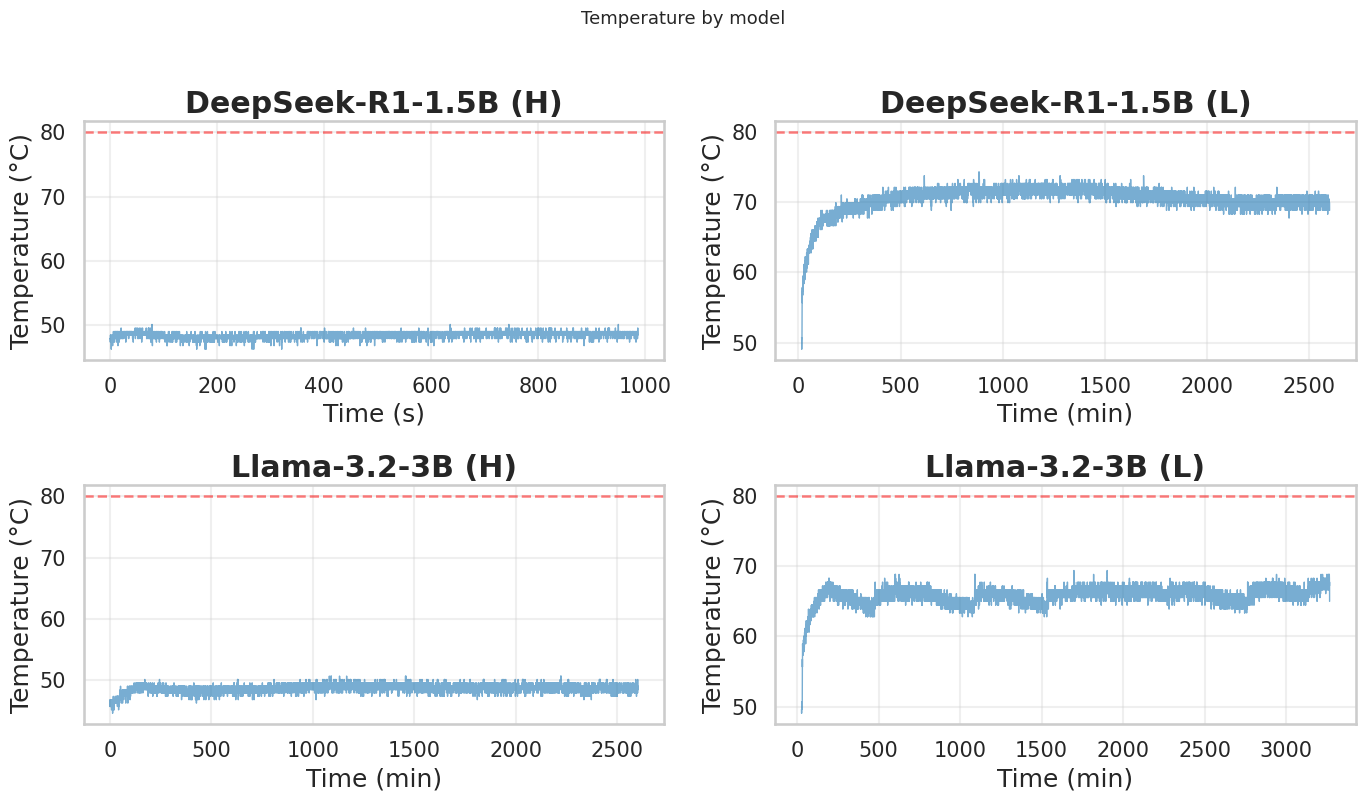

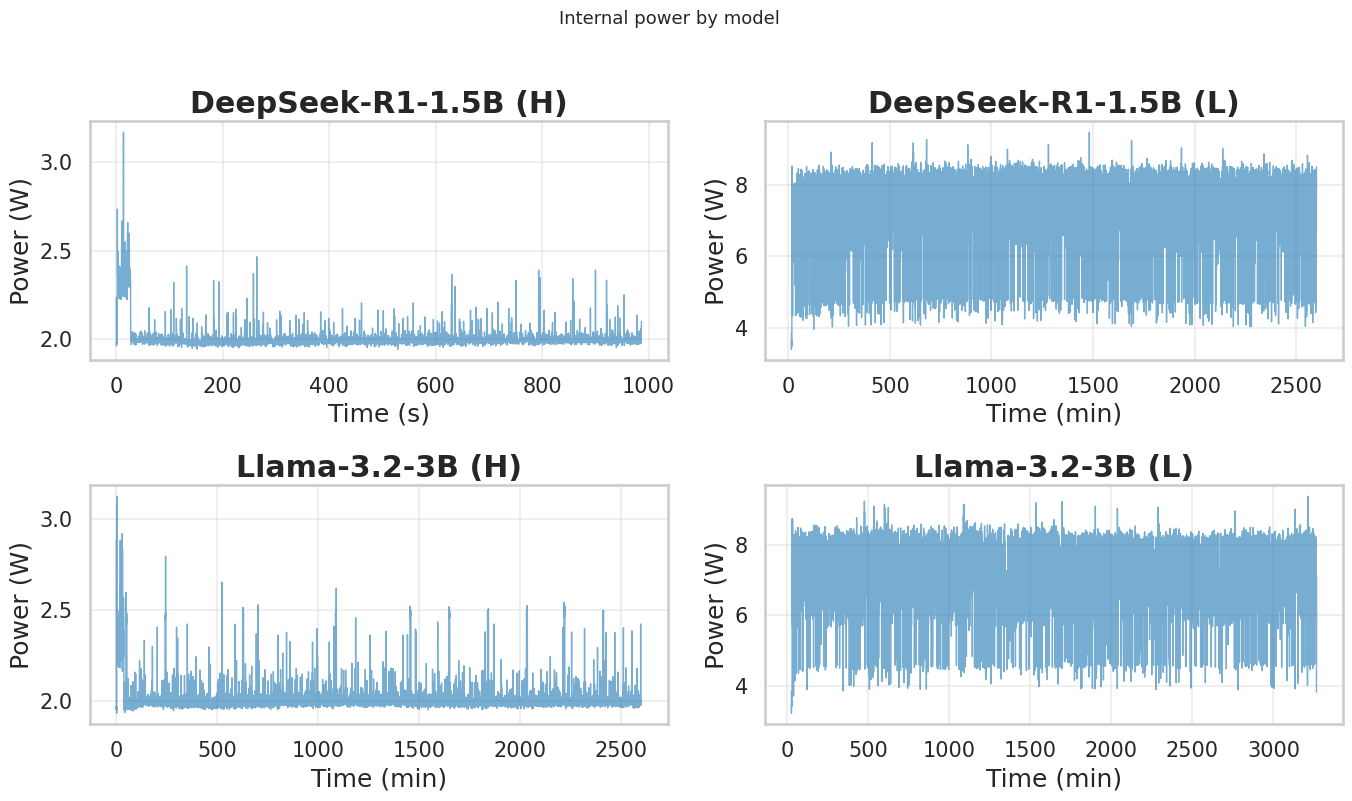

In [8]:
# Temperature and power timelines (small multiples, 2 columns)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nNo data", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        # Plot each run separately (fast matplotlib lines, no seaborn aggregation)
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub[y_col].values, alpha=0.6, linewidth=1)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Time (min)" if total_s > 1800 else "Time (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperature (°C)",
                   "Temperature by model", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Power (W)",
                   "Internal power by model")
else:
    print("No hardware data for timelines")


/tmp/ipykernel_254090/2260104133.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


/tmp/ipykernel_254090/2260104133.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


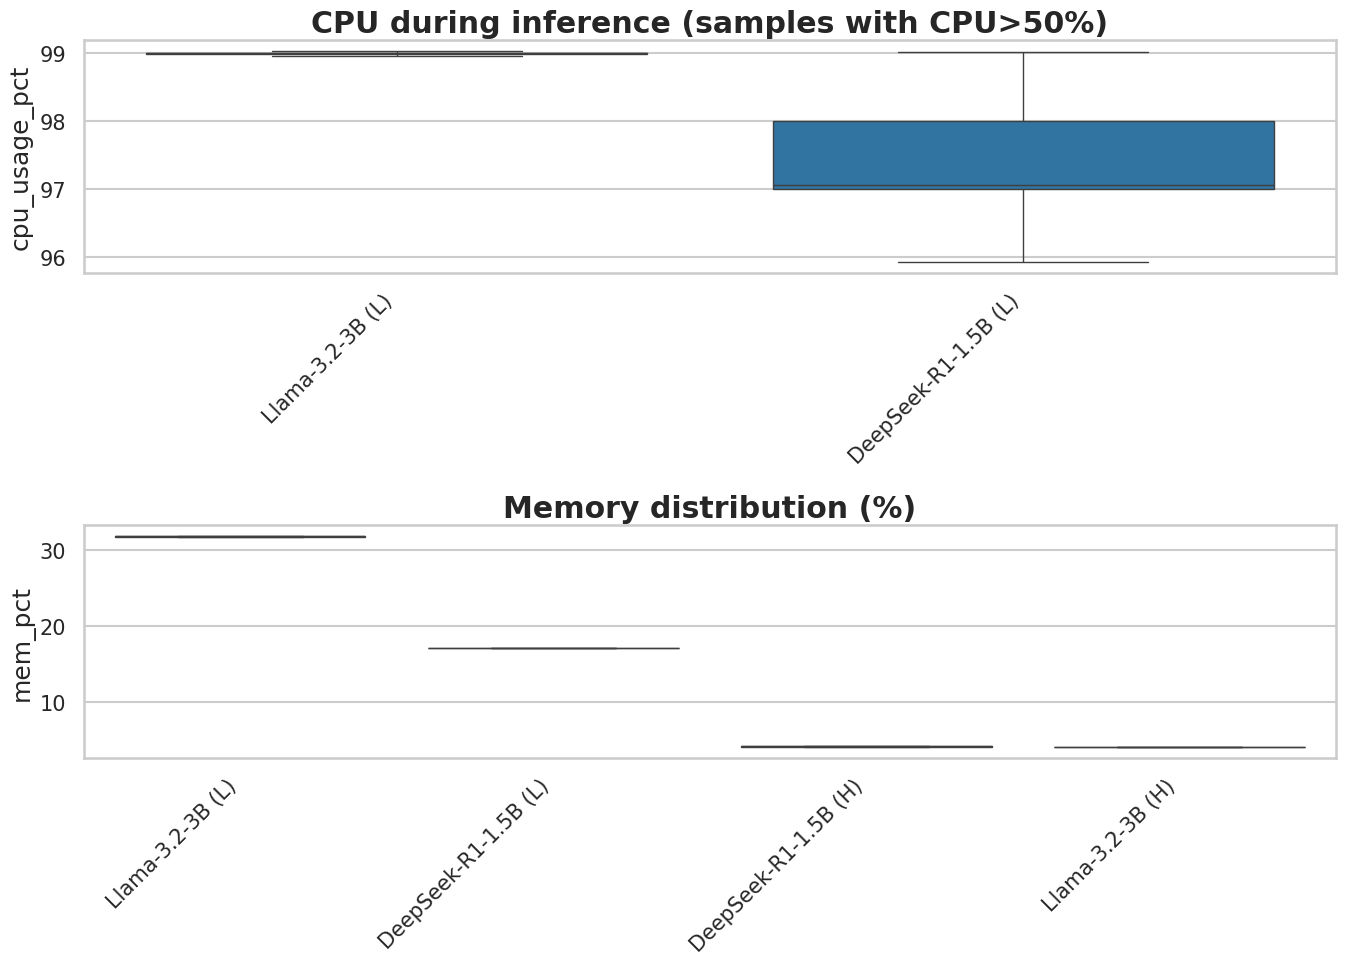

/tmp/ipykernel_254090/2260104133.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


/tmp/ipykernel_254090/2260104133.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


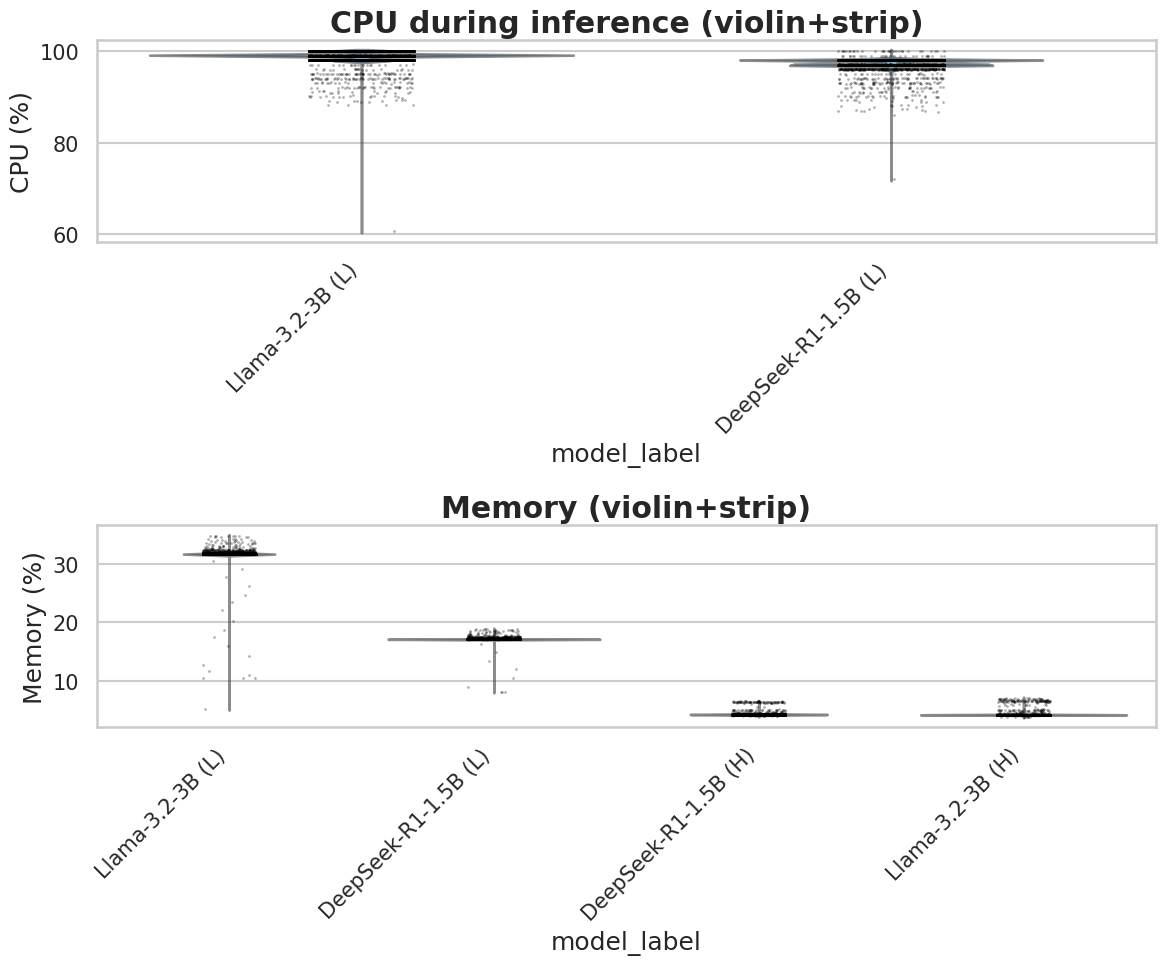

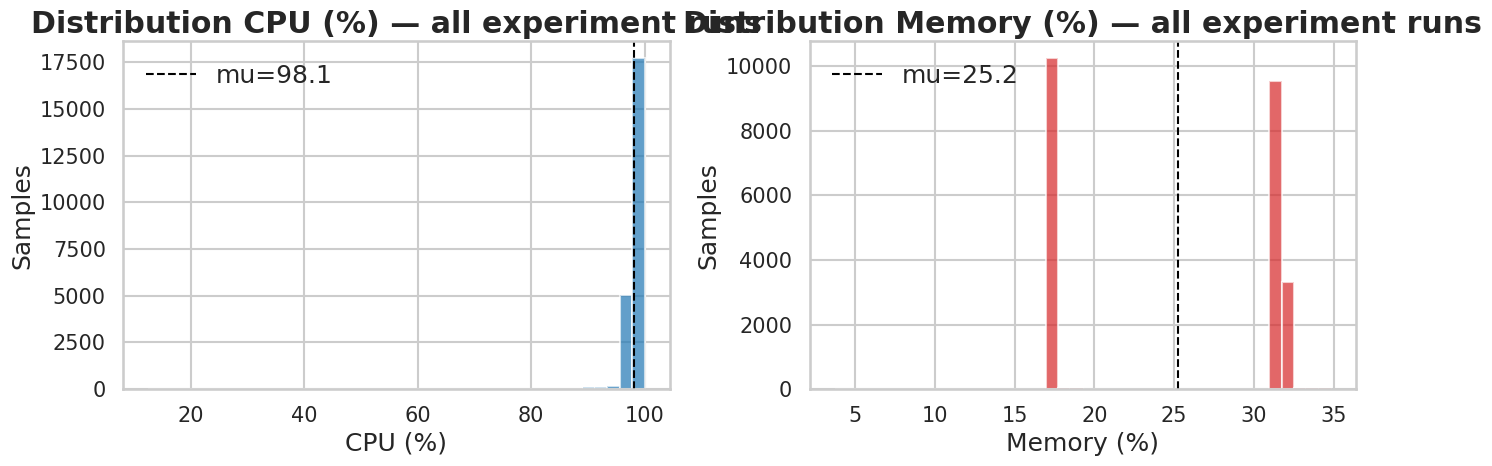

In [9]:
# Section 5a — CPU and Memory boxplot
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU during inference (samples with CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Memory distribution (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Section 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU during inference (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memory (violin+strip)")
    axes[1].set_ylabel("Memory (%)")
    fig.tight_layout()
    plt.show()

    # Section 5c — Aggregated histograms
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memory (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Samples")
            ax.set_title(f"Distribution {xlabel} — all experiment runs")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No hardware data for CPU/Memory distributions")


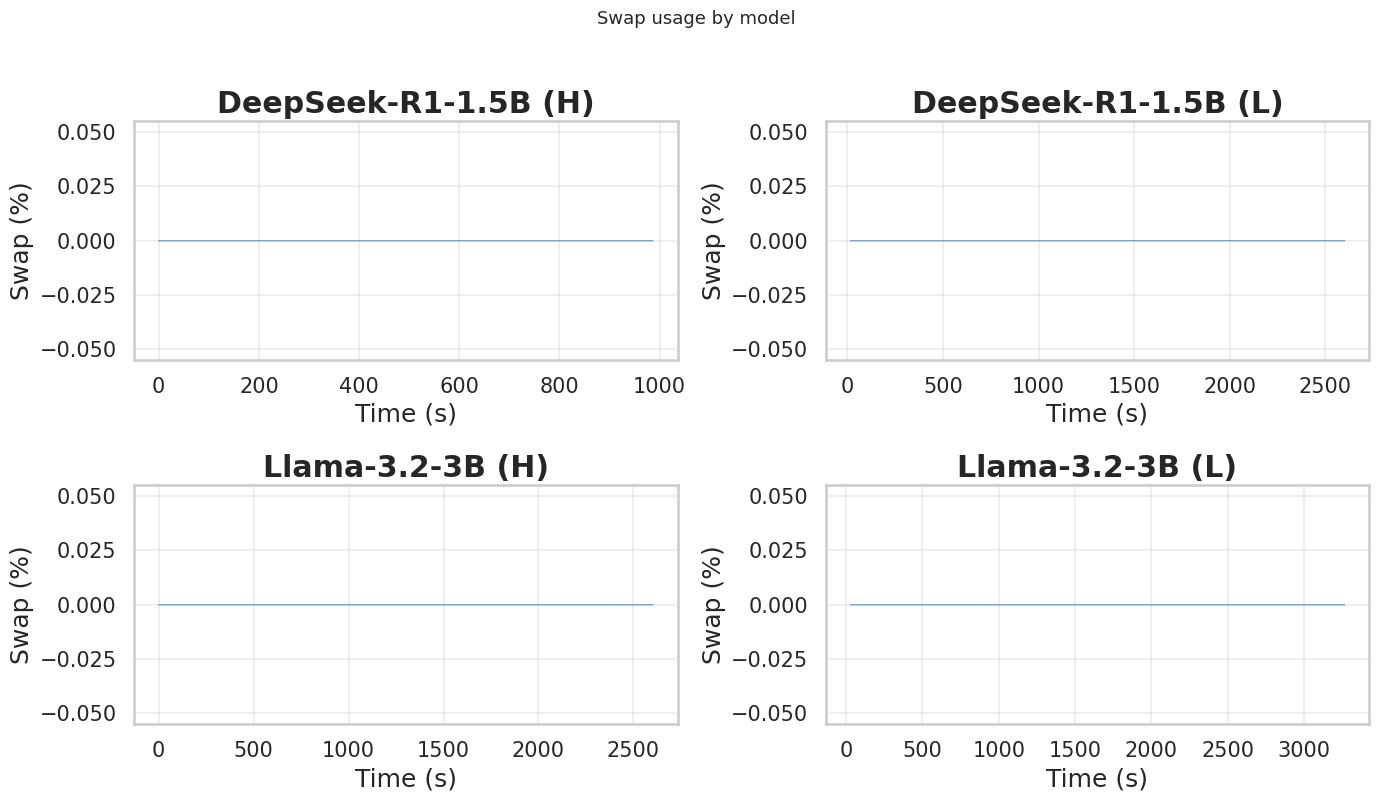

In [10]:
# Swap by model (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nNo data", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Swap usage by model", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("No hardware data for swap")


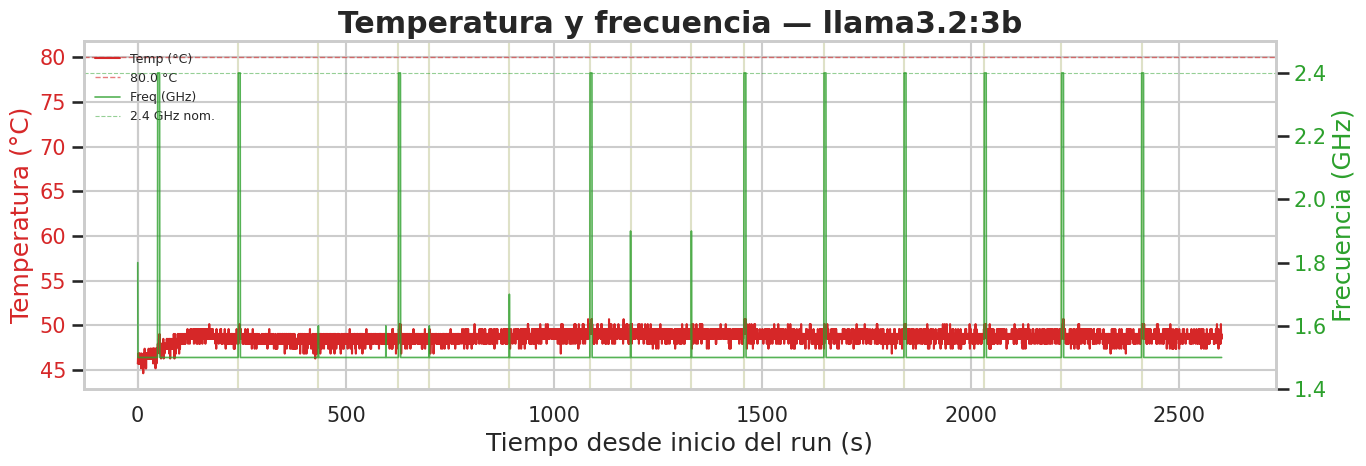

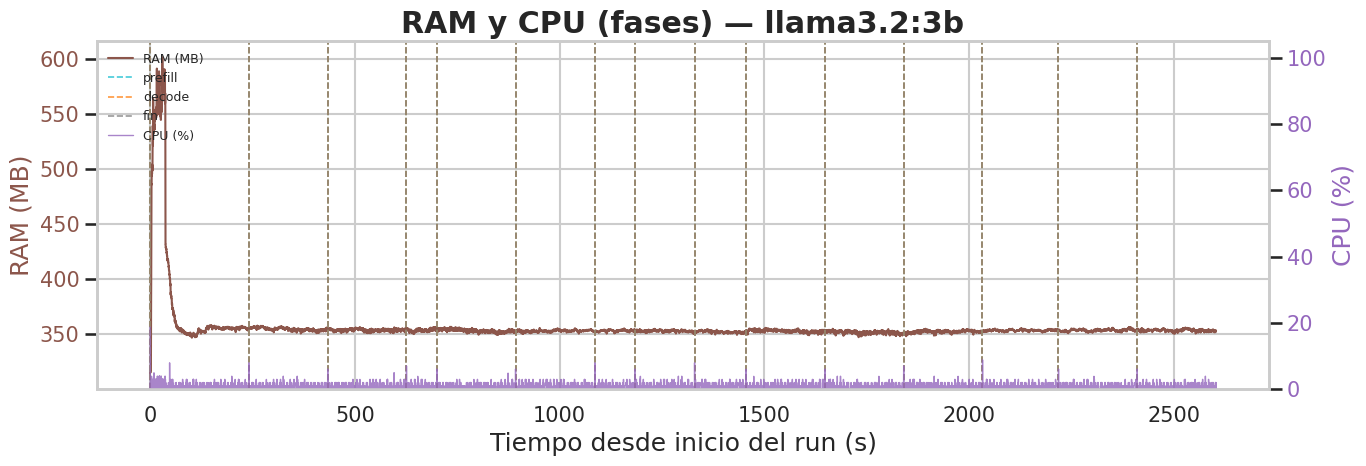

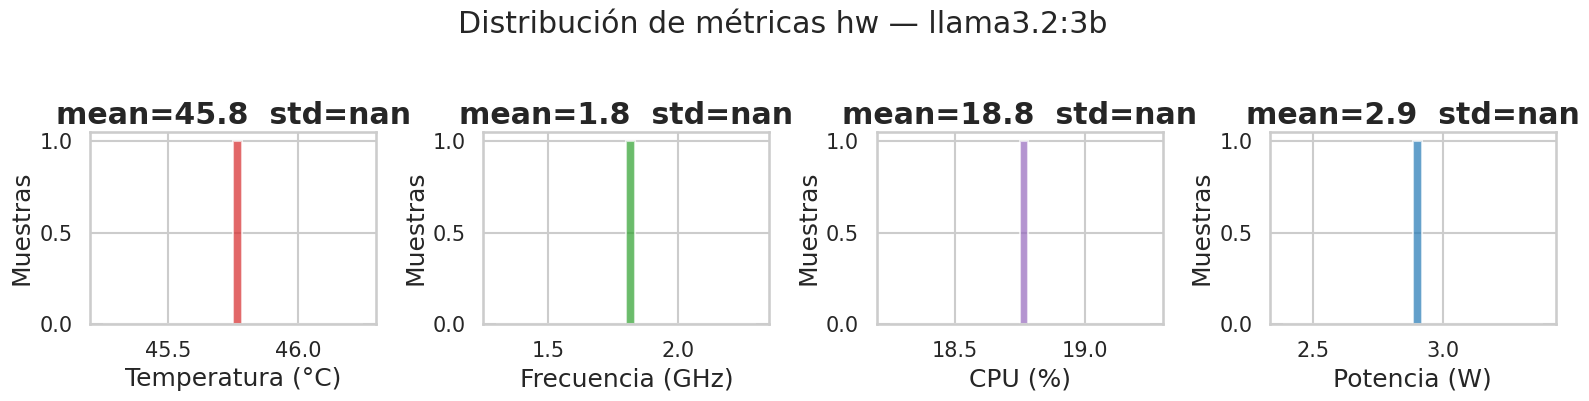

In [11]:
# Detailed analysis of a representative run (median duration)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No representative run found")
else:
    print("No data for detailed analysis")


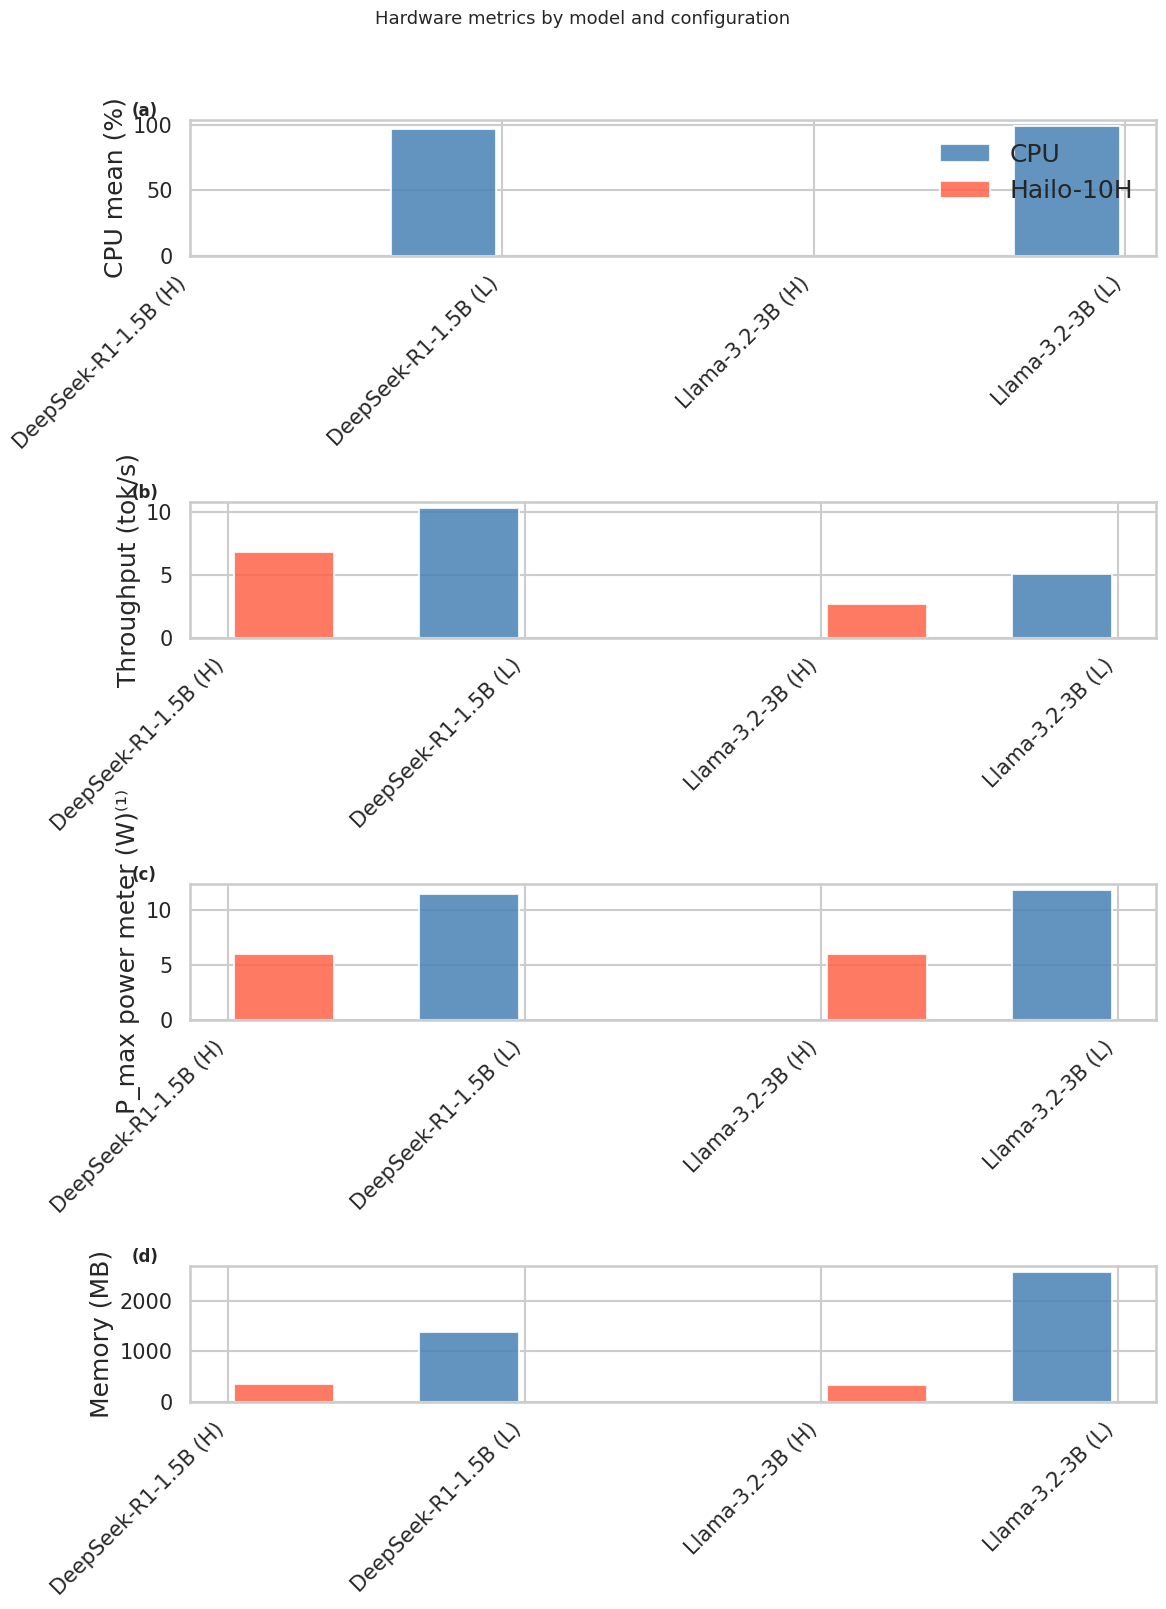

⁽¹⁾ Instantaneous peak from the external power meter (±2%).


In [12]:
# Hardware grouped bar chart (4 panels: CPU%, Throughput, P_max power meter, Memory)
import re

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str("Hailo-10H" if row.get("accelerator", False) else "CPU")
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "watt_max": row.get("watt_max_w", float("nan")),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",   "CPU mean (%)",            "(a)"),
        ("tokens_s",  "Throughput (tok/s)",      "(b)"),
        ("watt_max",  "P_max power meter (W)⁽¹⁾", "(c)"),
        ("mem_mb",    "Memory (MB)",             "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique())
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
    for i, (ax, (col, ylabel, label)) in enumerate(zip(axes, METRICS)):
        data = hw_summary.dropna(subset=[col])
        for j, (cfg, color) in enumerate(zip(configs, colors)):
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            ax.bar(x_pos + offset, vals, width * 0.9, label=cfg, color=color, alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.text(-0.06, 1.03, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
        if col == "cpu_pct":
            ax.legend(loc="upper right")
    fig.suptitle("Hardware metrics by model and configuration", y=1.01, fontsize=13)
    fig.tight_layout()
    plt.show()
    print("⁽¹⁾ Instantaneous peak from the external power meter (±2%).")
else:
    print("No data for hardware grouped bar chart")


/tmp/ipykernel_254090/3561634637.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


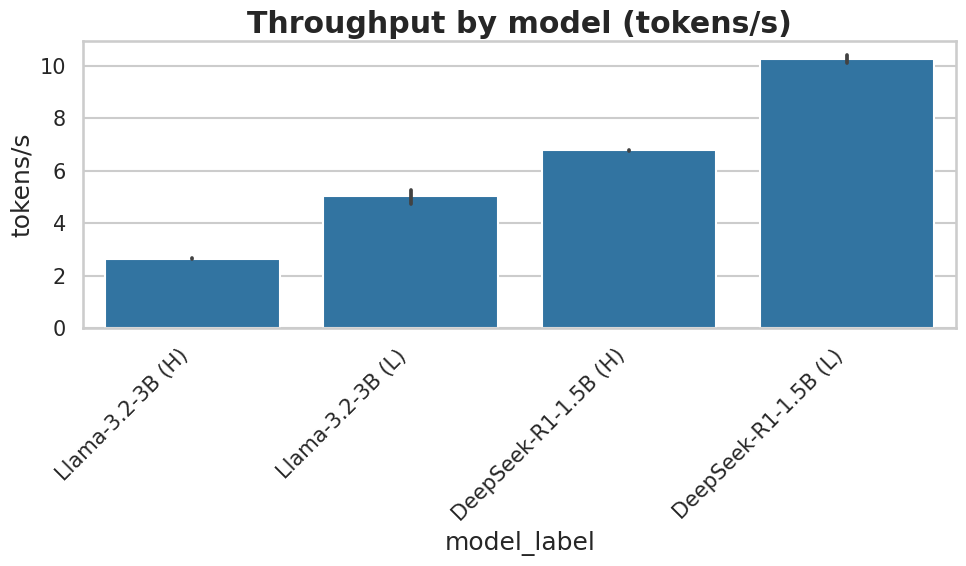

/tmp/ipykernel_254090/3561634637.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


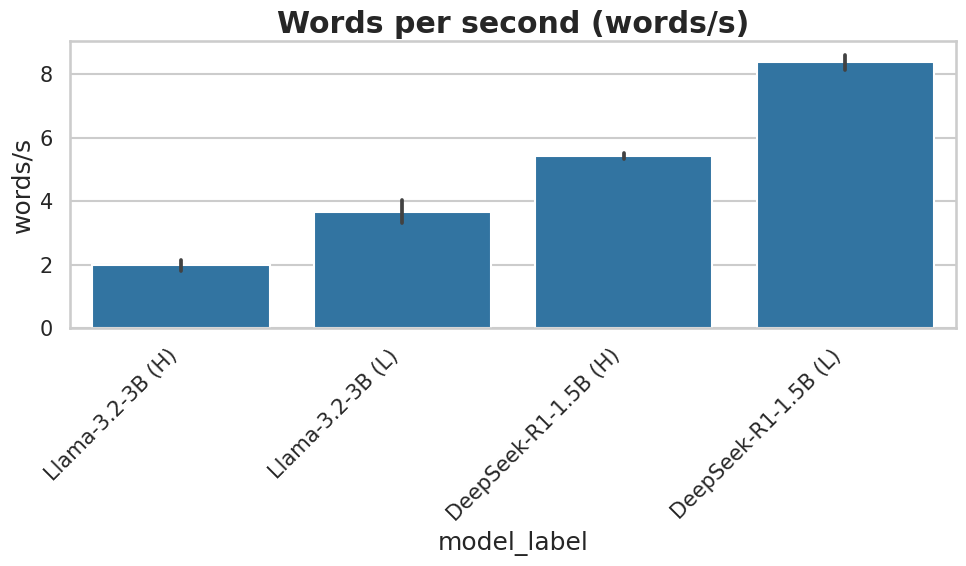

/tmp/ipykernel_254090/3561634637.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


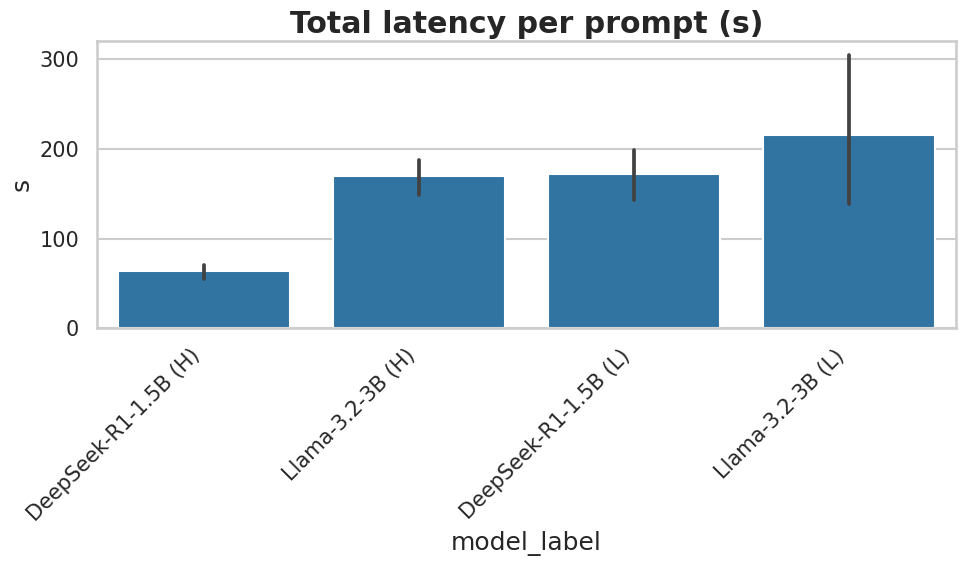

/tmp/ipykernel_254090/3561634637.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


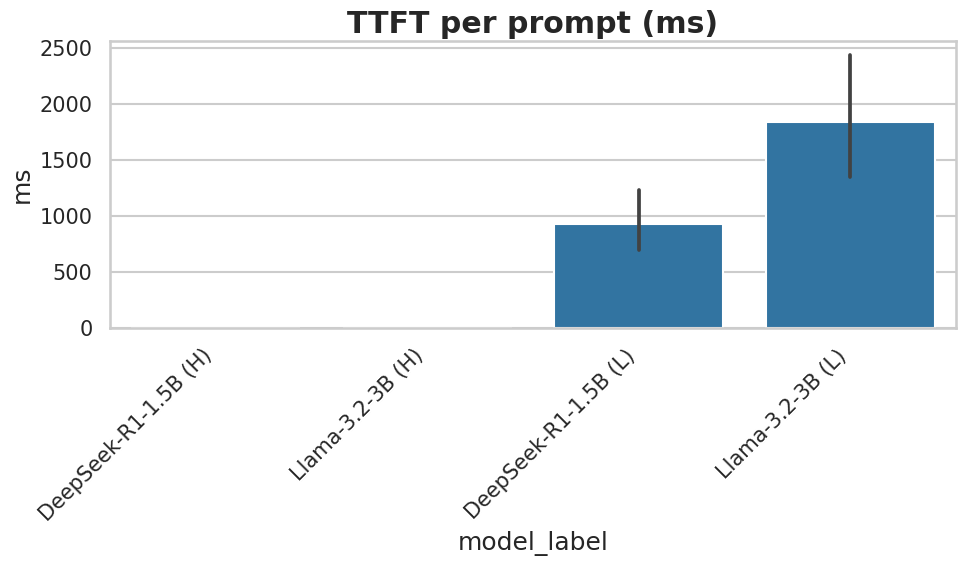

/tmp/ipykernel_254090/3561634637.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


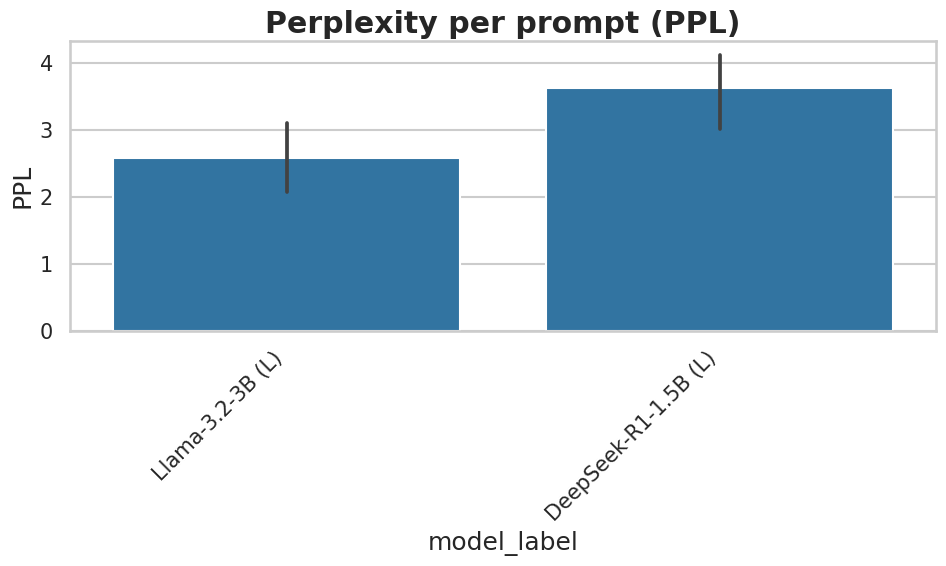

In [13]:
# Inference metrics by model
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput by model",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "words/s", "Words per second",
                 unit_label="words/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Total latency per prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT per prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplexity per prompt",
                     unit_label="PPL")
else:
    print("No inference data")


/tmp/ipykernel_254090/4059425384.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


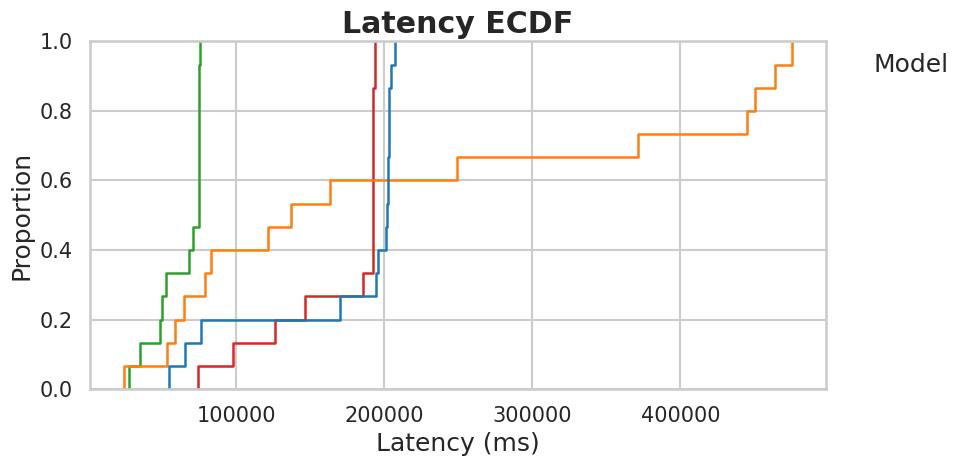

/tmp/ipykernel_254090/4059425384.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


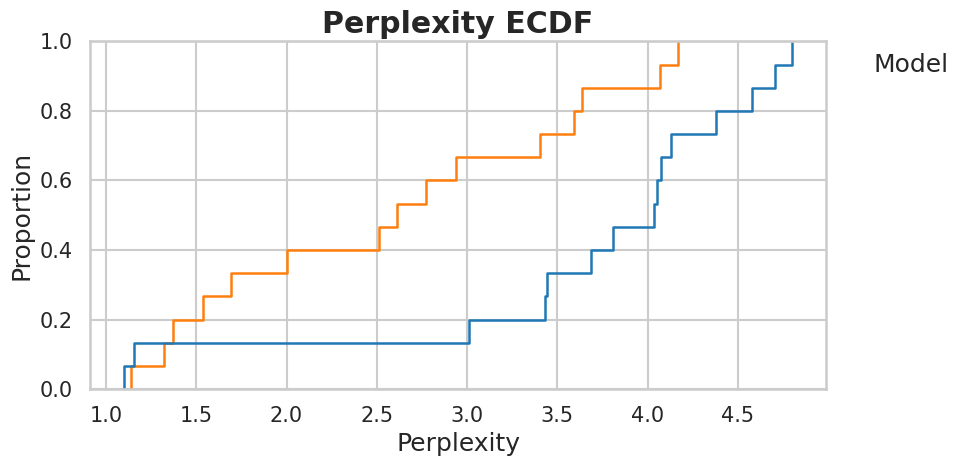

In [14]:
# ECDFs of latency and perplexity
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("Latency ECDF")
    ax.set_xlabel("Latency (ms)")
    ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("Perplexity ECDF")
        ax.set_xlabel("Perplexity")
        ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("No data for ECDFs")


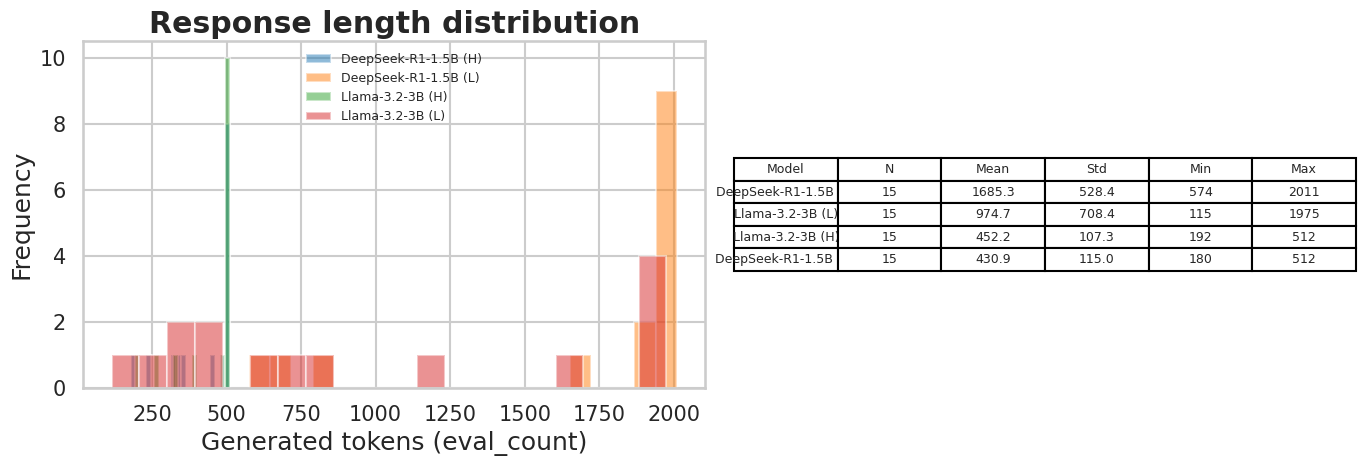

In [15]:
# Response length distribution
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Generated tokens (eval_count)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Response length distribution")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Model", "N", "Mean", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("No data for response length distribution")


In [16]:
# E5-specific analysis: CPU vs Hailo-10H
cpu_data   = ex[ex["accelerator"] == False]
hailo_data = ex[ex["accelerator"] == True]
if not cpu_data.empty and not hailo_data.empty:
    common = sorted(set(cpu_data["model_label"]) & set(hailo_data["model_label"]))
    if common:
        cpu_tps   = [cpu_data[cpu_data["model_label"] == m]["tokens_per_s_mean"].mean() for m in common]
        hailo_tps = [hailo_data[hailo_data["model_label"] == m]["tokens_per_s_mean"].mean() for m in common]
        speedup   = [h / c if c > 0 else float("nan") for c, h in zip(cpu_tps, hailo_tps)]
        x = np.arange(len(common))
        w = 0.35
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].bar(x - w / 2, cpu_tps, w, label="CPU", alpha=0.8)
        axes[0].bar(x + w / 2, hailo_tps, w, label="Hailo-10H", alpha=0.8)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(common, rotation=45, ha='right')
        axes[0].set_ylabel("tokens/s")
        axes[0].set_title("CPU vs Hailo-10H")
        axes[0].legend()
        axes[1].bar(range(len(common)), speedup, alpha=0.8, color="seagreen")
        axes[1].axhline(1.0, ls="--", color="black", alpha=0.5)
        axes[1].set_xticks(range(len(common)))
        axes[1].set_xticklabels(common, rotation=45, ha='right')
        axes[1].set_ylabel("Speedup")
        axes[1].set_title("Hailo/CPU speedup")
        fig.tight_layout()
        plt.show()
        display(pd.DataFrame({"Model": common, "CPU": cpu_tps, "Hailo": hailo_tps,
                               "Speedup": speedup}).round(2))
        print("NOTE: HAT (Hailo Accelerator Tile) power is not measurable with vcgencmd.")
else:
    print("No comparable CPU vs Hailo data")


/tmp/ipykernel_254090/683604299.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


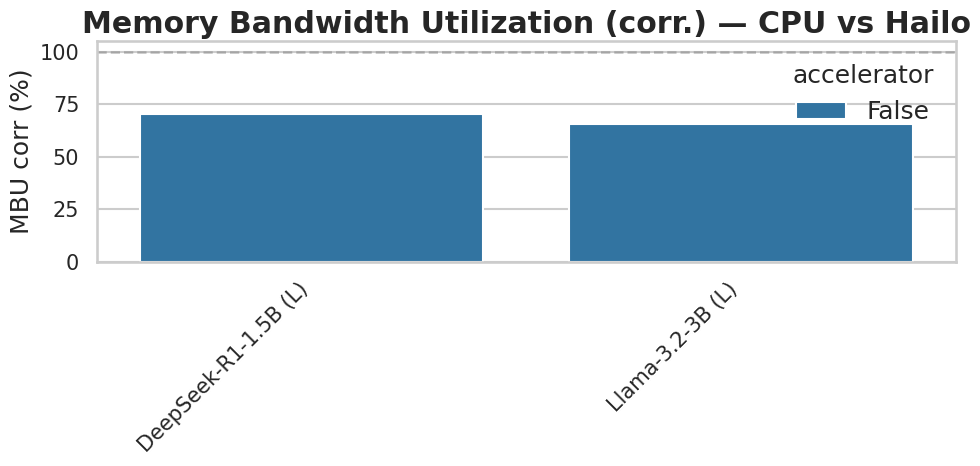

In [17]:
# MBU_corr — Memory Bandwidth Utilization (architecture-corrected)
from monitorviz.transforms.fom import compute_fom_full

try:
    _mbu_df = compute_fom_full(ex)
    _mbu_col = "mbu_corr"
    if _mbu_col in _mbu_df.columns and _mbu_df[_mbu_col].notna().any():
        _mbu_d = _mbu_df.dropna(subset=[_mbu_col])
        _acc_col = "accelerator" if "accelerator" in _mbu_d.columns else None
        _hue_mbu = _acc_col

        fig, ax = plt.subplots(figsize=(10, 5))
        _order = (_mbu_d.groupby("model_label")[_mbu_col]
                  .mean().sort_values(ascending=False).index)
        kw = dict(data=_mbu_d, x="model_label", y=_mbu_col, order=_order, ax=ax)
        if _hue_mbu and _hue_mbu in _mbu_d.columns:
            kw["hue"] = _hue_mbu
        sns.barplot(**kw)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_ylabel("MBU corr (%)")
        ax.set_xlabel("")
        ax.set_title("Memory Bandwidth Utilization (corr.) — CPU vs Hailo")
        ax.axhline(100, ls="--", color="gray", alpha=0.5)
        fig.tight_layout()
        plt.show()
    else:
        print("No mbu_corr column")
except Exception as e:
    print(f"Error in MBU: {e}")



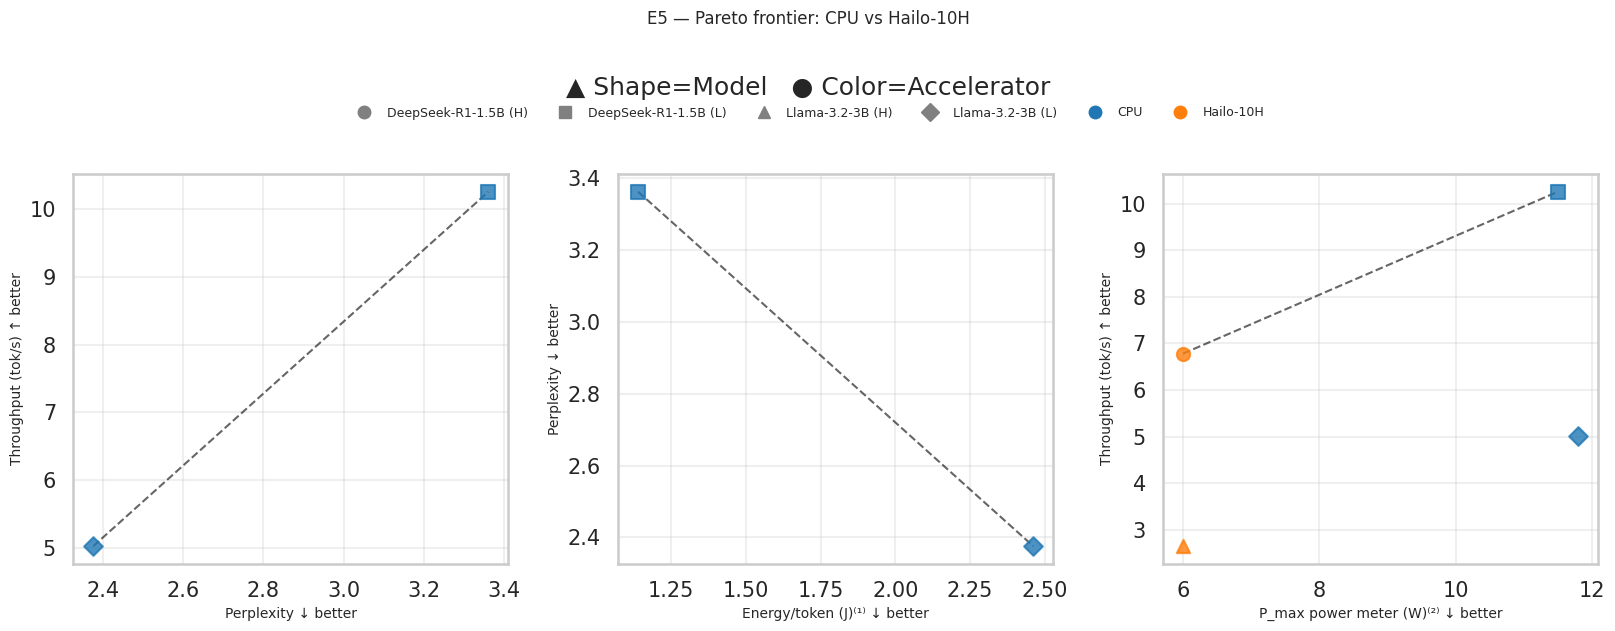

⁽¹⁾ Upper bound (includes power-on and ~5 min idle). ⁽²⁾ Instantaneous peak, power meter ±2%.


In [18]:
# Multidimensional trade-offs — Pareto frontier (E5)
from matplotlib.lines import Line2D as _L2D

def _pmask5(df, x_col, y_col, x_low, y_low):
    pts = df[[x_col, y_col]].to_numpy(dtype=float)
    dom = np.zeros(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i == j: continue
            xb = (pts[j,0] <= pts[i,0]) if x_low else (pts[j,0] >= pts[i,0])
            yb = (pts[j,1] <= pts[i,1]) if y_low else (pts[j,1] >= pts[i,1])
            if xb and yb and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                dom[i] = True; break
    return ~dom

_pareto_pairs5 = [
    ("perplexity_geomean", "tokens_per_s_mean", True,  False, "Perplexity",             "Throughput (tok/s)"),
    ("energy_per_token_j", "perplexity_geomean", True,  True,  "Energy/token (J)⁽¹⁾",   "Perplexity"),
    ("watt_max_w",         "tokens_per_s_mean",  True,  False, "P_max power meter (W)⁽²⁾","Throughput (tok/s)"),
]
valid_pairs5 = [(xc,yc,xl,yl,xlab,ylab) for xc,yc,xl,yl,xlab,ylab in _pareto_pairs5
                if xc in ex.columns and yc in ex.columns]

if valid_pairs5 and not ex.empty:
    _models5  = sorted(ex["model_label"].unique())
    _MK5      = ["o","s","^","D","v","P","X"]
    _MOD_MK5  = {m: _MK5[i % len(_MK5)] for i, m in enumerate(_models5)}

    _accs5    = sorted(ex["accelerator"].dropna().unique()) if "accelerator" in ex.columns else []
    _ACC_LABEL = {True: "Hailo-10H", False: "CPU"}
    _ACC_COL   = {True: "tab:orange", False: "tab:blue"}

    nc5 = len(valid_pairs5)
    fig, axes = plt.subplots(1, nc5, figsize=(nc5 * 5.5, 5.5))
    if nc5 == 1: axes = [axes]

    for ax, (xc, yc, xl, yl, xlabel, ylabel) in zip(axes, valid_pairs5):
        df_p = ex.dropna(subset=[xc, yc]).reset_index(drop=True)
        if df_p.empty: ax.set_visible(False); continue

        for model in _models5:
            for acc in _accs5:
                _sub = df_p[(df_p["model_label"]==model) & (df_p["accelerator"]==acc)]
                if _sub.empty: continue
                ax.scatter(_sub[xc], _sub[yc],
                           marker=_MOD_MK5[model],
                           color=_ACC_COL.get(acc, "tab:gray"),
                           s=90, alpha=0.8, zorder=3)

        mask = _pmask5(df_p, xc, yc, xl, yl)
        df_front = df_p[mask].sort_values(xc)
        if not df_front.empty:
            ax.plot(df_front[xc], df_front[yc], "k--", lw=1.5, alpha=0.6)

        ax.set_xlabel(xlabel + (" ↓ better" if xl else " ↑ better"), fontsize=10)
        ax.set_ylabel(ylabel + (" ↓ better" if yl else " ↑ better"), fontsize=10)
        ax.grid(True, alpha=0.3)

    _mod_h5 = [_L2D([],[],marker=_MOD_MK5[m],color="gray",ls="none",ms=9,label=m) for m in _models5]
    _acc_h5 = [_L2D([],[],marker="o",color=_ACC_COL.get(a,"tab:gray"),ls="none",ms=9,
                    label=_ACC_LABEL.get(a,str(a))) for a in _accs5]
    fig.legend(
        handles=_mod_h5 + _acc_h5,
        loc="upper center", bbox_to_anchor=(0.5, 1.06),
        ncol=min(len(_models5) + len(_accs5), 7), fontsize=9,
        title="▲ Shape=Model   ● Color=Accelerator"
    )
    fig.suptitle("E5 — Pareto frontier: CPU vs Hailo-10H", fontsize=12, y=1.16)
    fig.tight_layout()
    plt.show()
    print("⁽¹⁾ Upper bound (includes power-on and ~5 min idle). ⁽²⁾ Instantaneous peak, power meter ±2%.")
else:
    print("Insufficient columns for Pareto or no E5 data")


In [19]:
# Phase breakdown (if data available)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("No phase data")
except Exception as e:
    print(f"Error in phase_breakdown: {e}")


No phase data


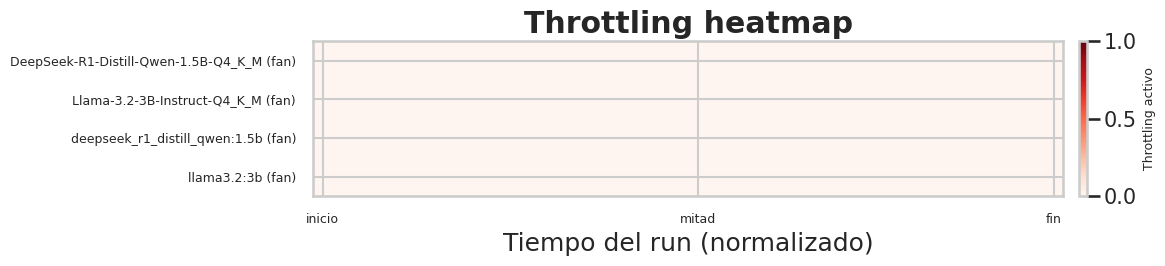

In [20]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("No hardware data for throttling heatmap")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Throttling heatmap")
        plt.show()
except Exception as e:
    print(f"Error in throttling_heatmap: {e}")


## Computational efficiency: effective CPU work

- **W_CPU (core·s)**: integrates `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), range [0,1]
- **W_token (core·s/token)**: CPU work per generated token


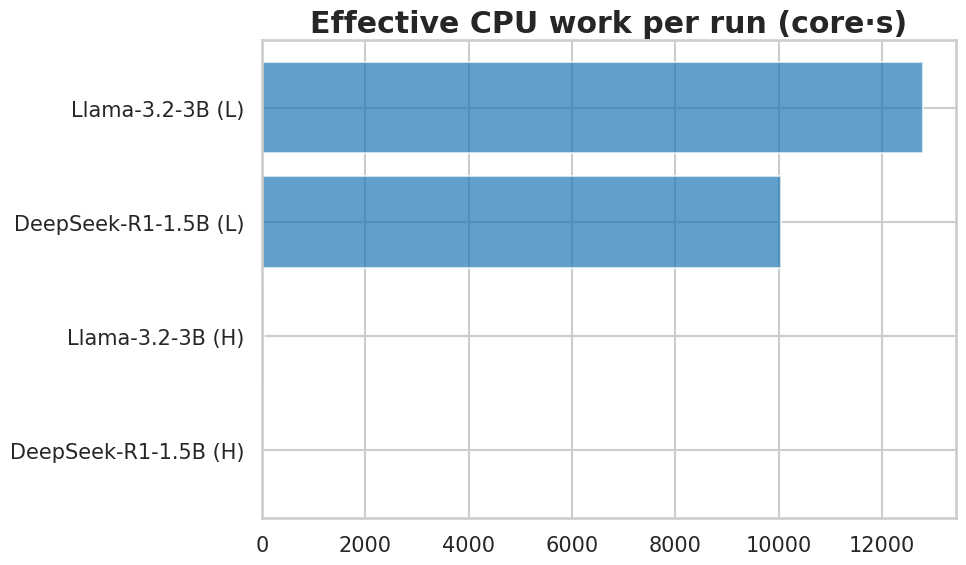

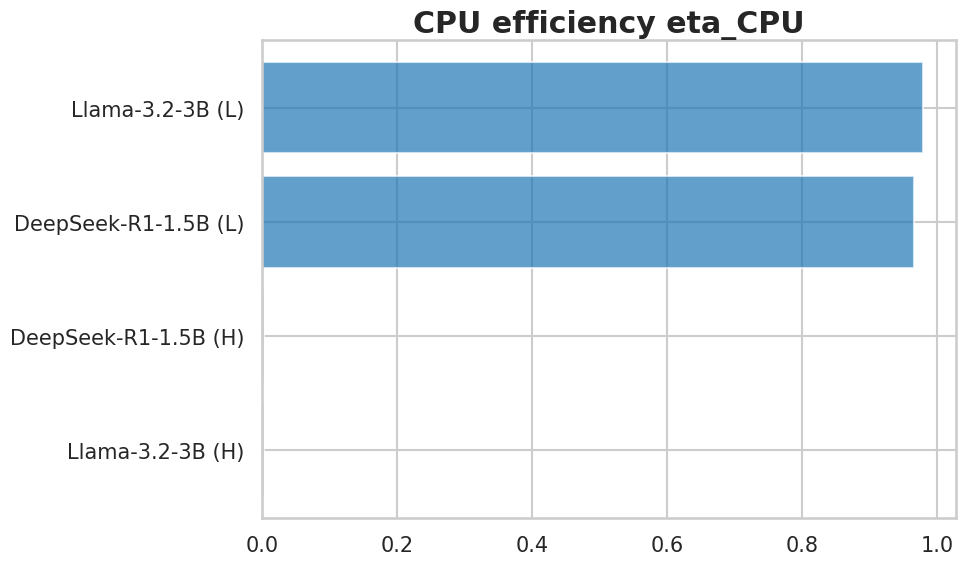

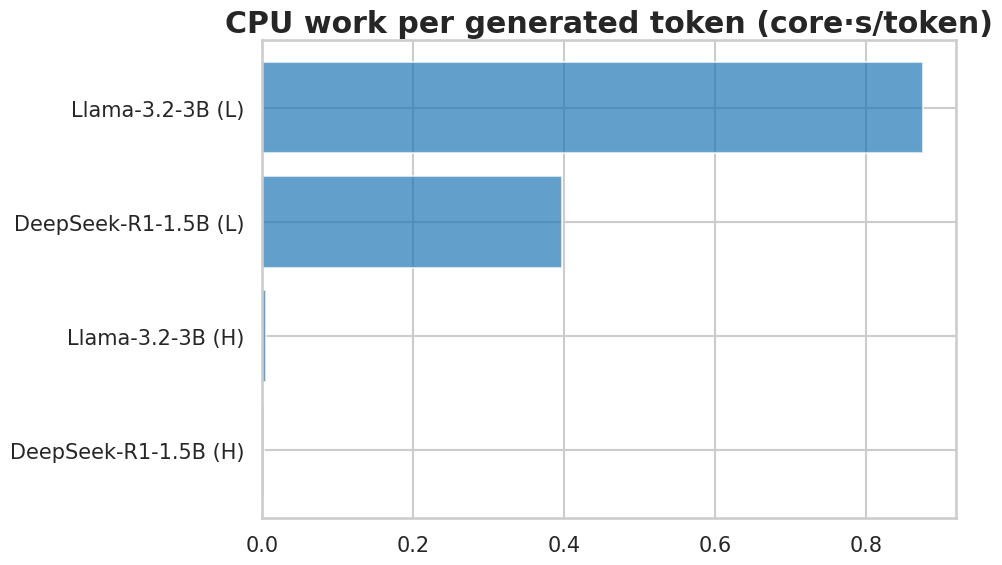

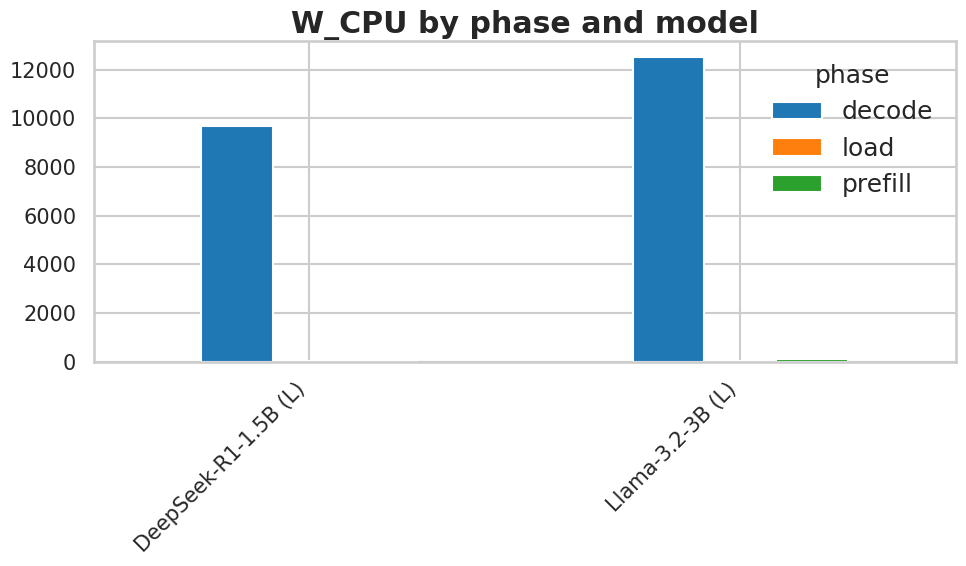

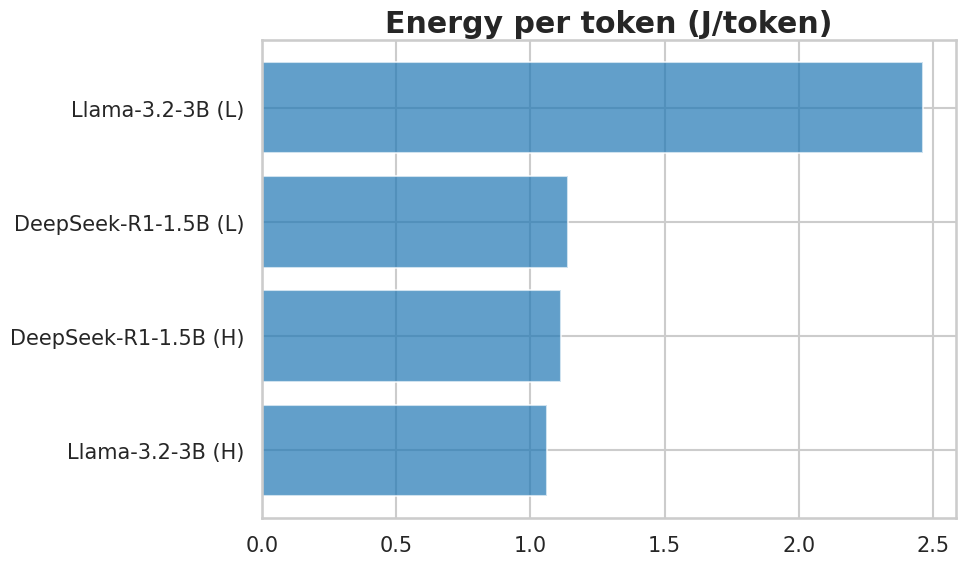

⁽¹⁾ J/tok computed from external power meter (total_kwh) in both configurations.
    Includes power-on and ~5 min idle — upper bound, comparable across substrates.


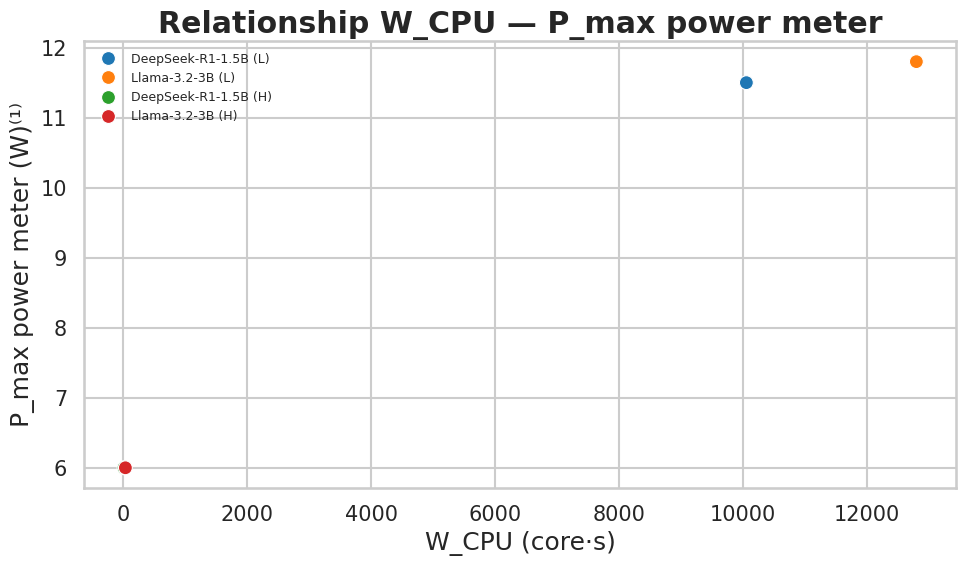

⁽¹⁾ Instantaneous peak from the external power meter (±2%).


In [21]:
# Computational and energy efficiency
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s",    "core·s",       "Effective CPU work per run"),
    ("cpu_efficiency",     "",             "CPU efficiency eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "CPU work per generated token"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Phase breakdown
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU by phase and model")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energy per token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energy per token", unit_label="J/token")
    print("⁽¹⁾ J/tok computed from external power meter (total_kwh) in both configurations.")
    print("    Includes power-on and ~5 min idle — upper bound, comparable across substrates.")

# Scatterplot W_CPU vs P_max power meter
if "cpu_work_core_s" in ex.columns and "watt_max_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "watt_max_w"])
    if not valid_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=valid_data, x="cpu_work_core_s", y="watt_max_w",
                        hue="model_label", s=100, ax=ax)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("P_max power meter (W)⁽¹⁾")
        ax.set_title("Relationship W_CPU — P_max power meter")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()
        print("⁽¹⁾ Instantaneous peak from the external power meter (±2%).")


In [22]:
# E4/E5: Section 18 — no architecture-specific scatter
print("Section 18: no architecture-specific analysis applies to this experiment.")


Section 18: no architecture-specific analysis applies to this experiment.


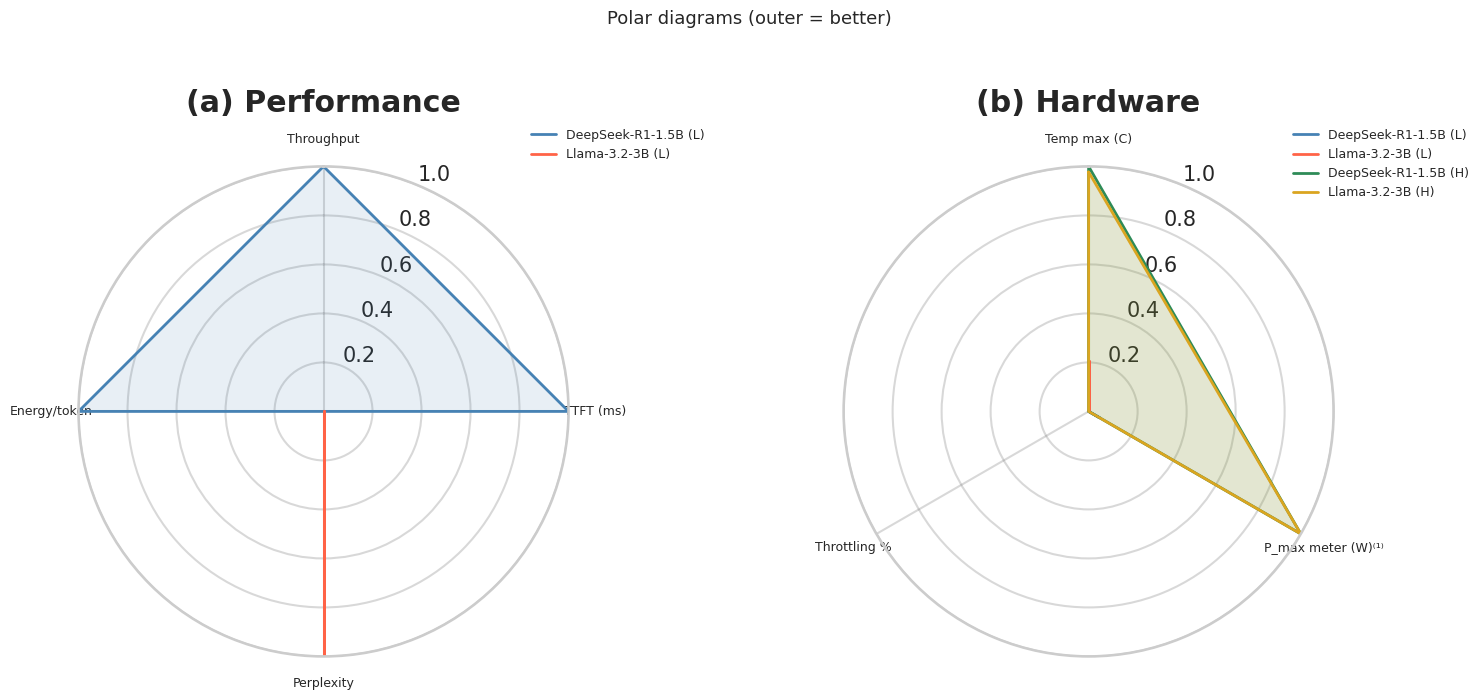

⁽¹⁾ Instantaneous peak from the external power meter (±2%).


In [23]:
# Polar diagrams (performance and hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",     True),
    ("ttft_ms_mean",       "TTFT (ms)",       False),
    ("perplexity_geomean", "Perplexity",      False),
    ("energy_per_token_j", "Energy/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",    "Temp max (C)",       False),
    ("watt_max_w",    "P_max meter (W)⁽¹⁾", False),
    ("throttled_ratio","Throttling %",      False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Performance", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Polar diagrams (outer = better)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("⁽¹⁾ Instantaneous peak from the external power meter (±2%).")


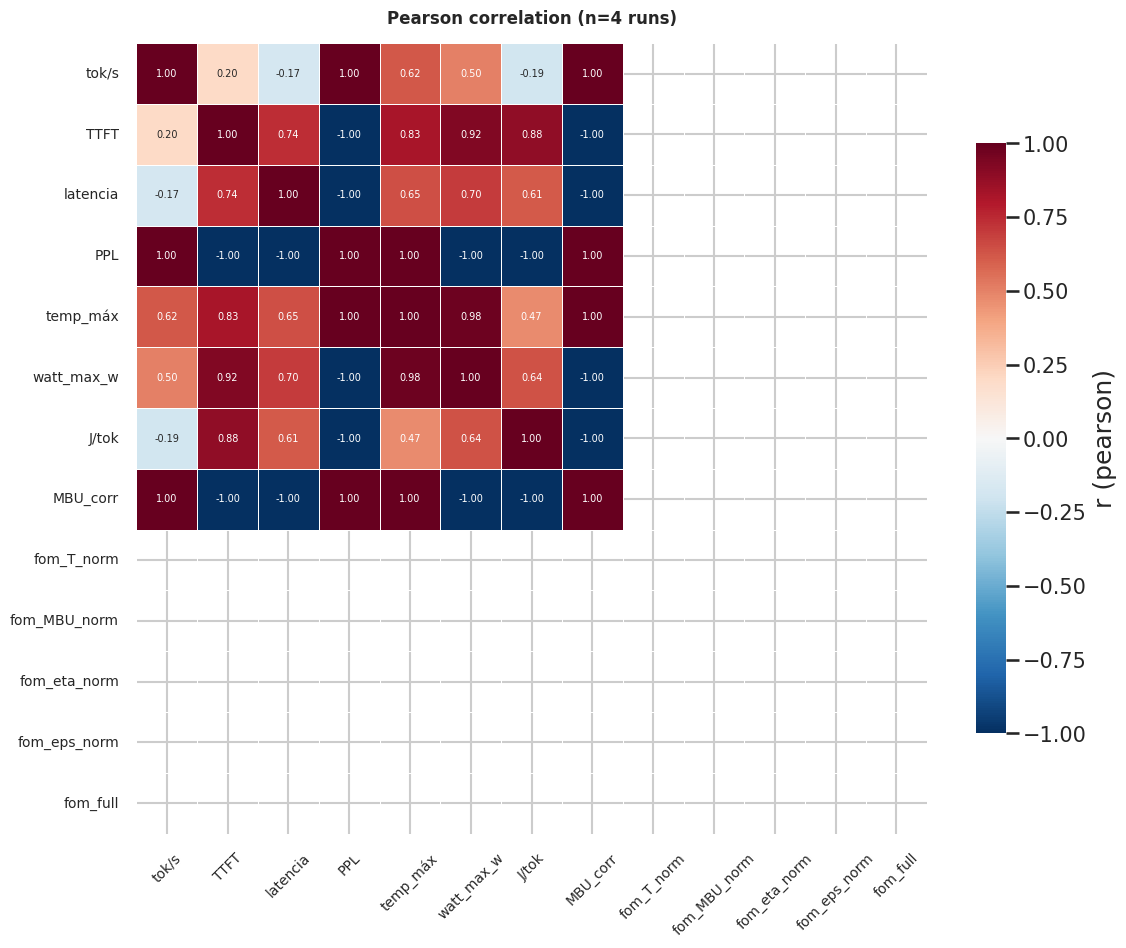

In [24]:
# Pearson correlation
try:
    from monitorviz.viz import correlation_heatmap
    from monitorviz.transforms.fom import compute_fom_full
    if len(ex) >= 3:
        _fom_p5 = compute_fom_full(ex)
        _pearson_cols5 = [c for c in [
            "tokens_per_s_mean", "ttft_ms_mean", "latency_ms_mean",
            "perplexity_geomean", "temp_max_c", "watt_max_w",
            "energy_per_token_j", "mbu_corr",
            "fom_T_norm", "fom_MBU_norm", "fom_eta_norm", "fom_eps_norm", "fom_full",
        ] if c in _fom_p5.columns]
        fig = correlation_heatmap(_fom_p5, cols=_pearson_cols5,
                                  title=f"Pearson correlation (n={len(_fom_p5)} runs)")
        plt.show()
    else:
        print(f"Insufficient data: {len(ex)} run(s), >=3 needed.")
except Exception as e:
    print(f"Error in correlation: {e}")


In [25]:
# Alerts and anomalies
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"empty generations: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERT: {a}")
if not alerts:
    print("No alerts detected")


No alerts detected


## Conclusions and discussion

### Hypothesis confirmation/refutation
> TODO

### Key findings
> TODO

### Limitations
> TODO
